In [21]:
import json
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

In [22]:
TASK_TYPE = 0
TARGET_ACCURACY = 0.9
MAX_FPS = 30
TOTAL_SECOND = 600

In [23]:
colors = ['skyblue', 'lightgreen', 'salmon']

In [24]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [25]:
def find_y_given_x(x_list, y_list, x_value, degree=3):
	"""
	Fits a polynomial relationship between x_list and y_list, and finds the corresponding y for a given x_value.
	
	Parameters:
		x_list (list or array-like): The list of x values.
		y_list (list or array-like): The list of y values corresponding to x_list.
		x_value (float): The x value for which we want to find the corresponding y.
		degree (int): The degree of the polynomial to fit. Default is 2 (quadratic fit).
	
	Returns:
		float: The predicted y value corresponding to x_value.
	"""
	# Ensure inputs are numpy arrays
	x_array = np.array(x_list)
	y_array = np.array(y_list)

	# Fit a polynomial model of the specified degree
	coefficients = np.polyfit(x_array, y_array, degree)
	polynomial = np.poly1d(coefficients)
	
	# Predict the y value for the given x_value
	y_value = polynomial(x_value)
	
	return y_value

In [26]:
def plot_bar_chart_with_variance(values, variances, categories, subcategories, title, x_label, y_label, fig_size, label_size=24, tick_size=16, legend_size=12):
	# Parameters for the grouped bar chart
	bar_width = 0.2
	x = np.arange(len(categories))  # Base positions for the categories
	

	# Create the figure and axes
	fig, ax = plt.subplots(figsize=(fig_size[0], fig_size[1]))

	# Plot bars with error bars
	for i, (value_set, variance_set) in enumerate(zip(values, variances)):
		ax.bar(
			x + i * bar_width,             # Offset for the subcategory
			value_set,                     # Heights of the bars
			bar_width,                     # Width of each bar
			yerr=variance_set,             # Variances for error bars
			capsize=5,                     # Error bar caps
			label=f'{subcategories[i]}',   # Legend label
			color=colors[i],               # Bar color
			edgecolor='black'              # Bar border color
		)

	# Customization
	ax.set_xlabel(x_label, fontsize=label_size)
	ax.set_ylabel(y_label, fontsize=label_size)
	ax.set_title(title, fontsize=label_size)
	ax.set_xticks(x + bar_width * (len(subcategories) - 1) / 2)
	ax.set_xticklabels(categories, fontsize=tick_size)
	plt.tick_params(axis='y', labelsize=tick_size)
	ax.legend(fontsize=legend_size)

	# Show the plot
	plt.tight_layout()
	plt.show()

In [27]:
overall_result_eva = load_json_file("./result/5.2.2/end_to_end_pipeline.json")
overall_result_reducto = load_json_file("./result/5.2.2/end_to_end_pipeline_reducto.json")

result_eva = overall_result_eva[str(TARGET_ACCURACY)][str(TASK_TYPE)]
result_reducto = overall_result_reducto[str(TARGET_ACCURACY)][str(TASK_TYPE)]

In [28]:
power_profile_directory = 'dataset/FPS-Power.json'
old_power_profile = load_json_file(os.path.join(power_profile_directory))
profiler_fps_list = [int(f) for f in list(old_power_profile.keys())]
profiler_power_list = [old_power_profile[str(f)] for f in profiler_fps_list]

for i in range(profiler_fps_list[-1]+1, MAX_FPS+1):
	iy = find_y_given_x(profiler_fps_list, profiler_power_list, i)
	profiler_fps_list.append(i)
	profiler_power_list.append(iy)

new_power_profile = {}
for i in range(len(profiler_fps_list)):
	new_power_profile[profiler_fps_list[i]] = profiler_power_list[i]

In [29]:
plot_video_names = list(result_reducto.keys())
plot_video_names = ['1', '7', '8', 'Video4']

eva_detection_energy_list = []
eva_profiing_energy_list = []
reducto_detection_energy_list = []
reducto_profiing_energy_list = []

for plot_video_name in plot_video_names:
	eva_dict = result_eva[plot_video_name]
	eva_fps_list = eva_dict['fps_list']
	eva_power_list = [new_power_profile[fps] for fps in eva_fps_list]
	eva_no_rp_fps_list = eva_dict['no_rp_fps_list']
	eva_no_rp_power_list = [new_power_profile[fps] for fps in eva_no_rp_fps_list]

	reducto_dict = result_reducto[plot_video_name]
	reducto_fps_list = reducto_dict['fps_list']
	reducto_power_list = [new_power_profile[fps] for fps in reducto_fps_list]
	reducto_no_rp_fps_list = reducto_dict['no_rp_fps_list']
	reducto_no_rp_power_list = [new_power_profile[fps] for fps in reducto_no_rp_fps_list]

	print(plot_video_name)

	assert(eva_dict['test_length'] == reducto_dict['test_length'])

	test_length = eva_dict['test_length']
	multiplier = 1. * TOTAL_SECOND / test_length

	eva_detection_energy = np.sum(eva_no_rp_power_list) * multiplier
	eva_profiing_energy = np.sum(np.array(eva_power_list) - np.array(eva_no_rp_power_list)) * multiplier
	reducto_detection_energy = np.sum(reducto_no_rp_power_list) * multiplier
	reducto_profiing_energy = np.sum(np.array(reducto_power_list) - np.array(reducto_no_rp_power_list)) * multiplier

	print(eva_detection_energy)
	print(eva_profiing_energy)
	print(reducto_detection_energy)
	print(reducto_profiing_energy)

	eva_detection_energy_list.append(eva_detection_energy)
	eva_profiing_energy_list.append(eva_profiing_energy)
	reducto_detection_energy_list.append(reducto_detection_energy)
	reducto_profiing_energy_list.append(reducto_profiing_energy)

	print("")

1
4224.567760113079
701.4032977413701
8693.758183821996
780.0243620566084

7
3104.048027417614
1250.2325557726515
9333.765371335237
1236.4549782618774

8
5759.324052968329
703.8354798684258
10627.669392663935
553.5652878953881

Video4
4525.121837148268
1102.1968085199474
5042.284145284186
2418.854422710945



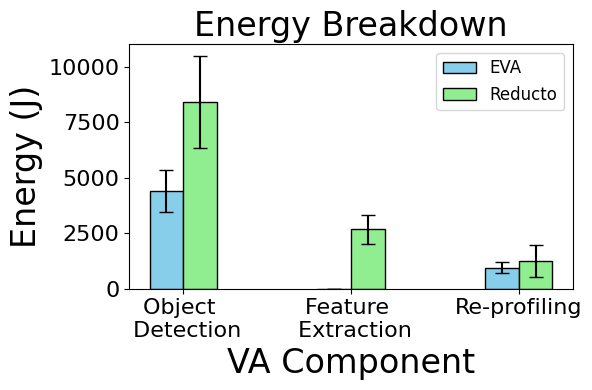

In [30]:
feature_ratio = np.mean(np.array([0.3735548, 0.24649585, 0.33179041]))
reducto_feature_energy_list = list(np.array(reducto_detection_energy_list) * feature_ratio)
eva_feature_energy_list = np.zeros(len(reducto_feature_energy_list))

bar_values = [
    [
        np.mean(np.array(eva_detection_energy_list)),
        np.mean(np.array(eva_feature_energy_list)),
        np.mean(np.array(eva_profiing_energy_list)),
    ],
    [
        np.mean(np.array(reducto_detection_energy_list)),
        np.mean(np.array(reducto_feature_energy_list)),
        np.mean(np.array(reducto_profiing_energy_list)),
    ],
]

bar_variances = [
    [
        np.std(np.array(eva_detection_energy_list)),
        np.std(np.array(eva_feature_energy_list)),
        np.std(np.array(eva_profiing_energy_list)),
    ],
    [
        np.std(np.array(reducto_detection_energy_list)),
        np.std(np.array(reducto_feature_energy_list)),
        np.std(np.array(reducto_profiing_energy_list)),
    ],
]

categories = ['Object \n Detection', 'Feature \n Extraction', 'Re-profiling']
subcategories = ['EVA', 'Reducto']

plot_bar_chart_with_variance(bar_values, bar_variances, categories, subcategories, 'Energy Breakdown', 'VA Component', 'Energy (J)', (6, 4))